<div class="alert alert-block alert-info"> 
    <center><h1 "> Tarea 6: Cálculo Científico I - MAT2605</h1> </center>
</div>
    <!-- <b></b>     -->
    <h4 style="color:#173F8A;;text-align:right;"> Profesor: Manuel A. Sánchez<br> Ayudantes: Diego Vera, Tomás Malfetano <br></h4>

<!-- 
<div class="alert alert-block alert-success"> Use green boxes sparingly, and only for some specific purpose that the other boxes can't cover. For example, if you have a lot of related content to link to, maybe you decide to use green boxes for related links from each section of a notebook. </div>

<div class="alert alert-block alert-warning"> Use yellow boxes for examples that are not inside code cells, or use for mathematical formulas if needed. </div>

<div class="alert alert-block alert-danger"> In general, just avoid the red boxes. </div>

############# Markdown parser in Sphinx ##################

<div class="admonition note"> <p class="admonition-title">Note</p> <p>You should note that the title will be automatically capitalized.</p> </div>

<div class="admonition danger"> <p class="admonition-title">Don't try this at home</p> <p>...</p> </div>
 -->
<!-- <div class="admonition important"> <p>This is an admonition box without a title.</p> </div> -->

<div class="alert alert-block alert-success"> <b> Nombre de estudiante: </b> Rafael Ignacio Lorca Muñoz</div>


In [2]:
import numpy as np
import matplotlib.pyplot as plt

<div class="alert alert-block alert-info"> <b> Problema 1. Mínimos cuadrados </b> </div>

Considere la función $f(x) = \sin(\pi  x/2) + \pi x/2$ con $x\in[-8,8]$. Ajuste por mínimos cuadrados el polinomio  $p_n\in \mathcal P_n$ que minimiza el error cuadrático medio
$$
\sum_{i=1}^{100} | f(x_i) - p_n(x_i)|^{2}
$$
donde $x_i$ son 100 puntos equiespaciados del intervalo $[-8,8]$. Calcule para $n = 2,4,8,16,32$. Grafique los polinomios y la función  $f(x)$. Observe y comente acerca de las aproximaciones.

<div class="alert alert-block alert-success"> <b> Solución. </b> </div>

x: [-8.  8.]
y: [-12.56637061  12.56637061]


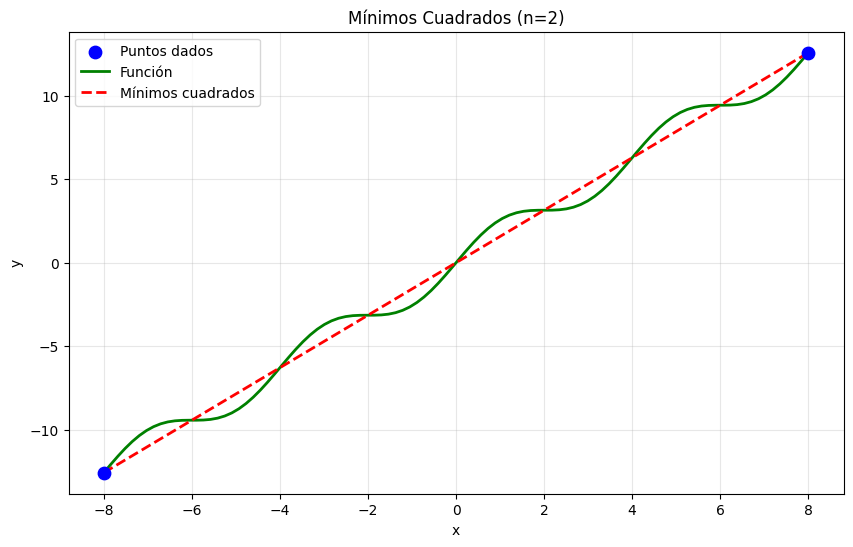

x: [-8.         -2.66666667  2.66666667  8.        ]
y: [-12.56637061  -3.3227648    3.3227648   12.56637061]


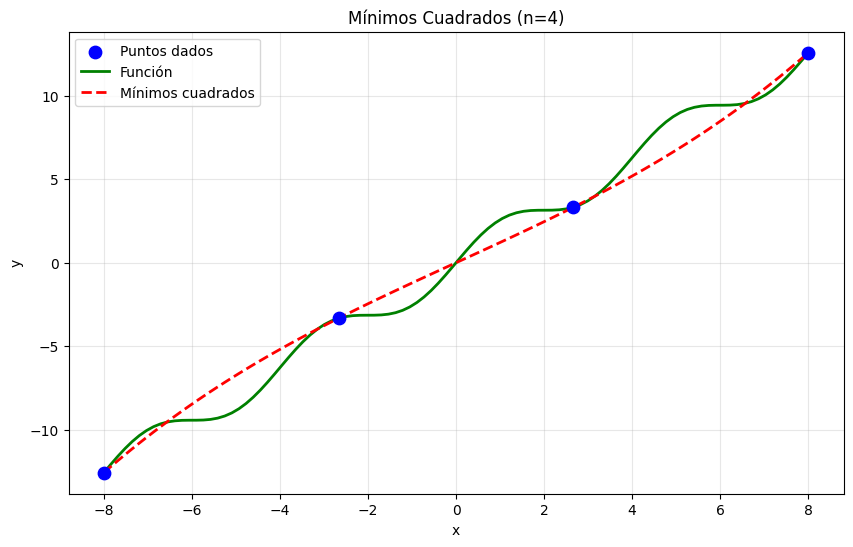

x: [-8.         -5.71428571 -3.42857143 -1.14285714  1.14285714  3.42857143
  5.71428571  8.        ]
y: [-12.56637061  -9.40986275  -4.60375592  -2.77012371   2.77012371
   4.60375592   9.40986275  12.56637061]


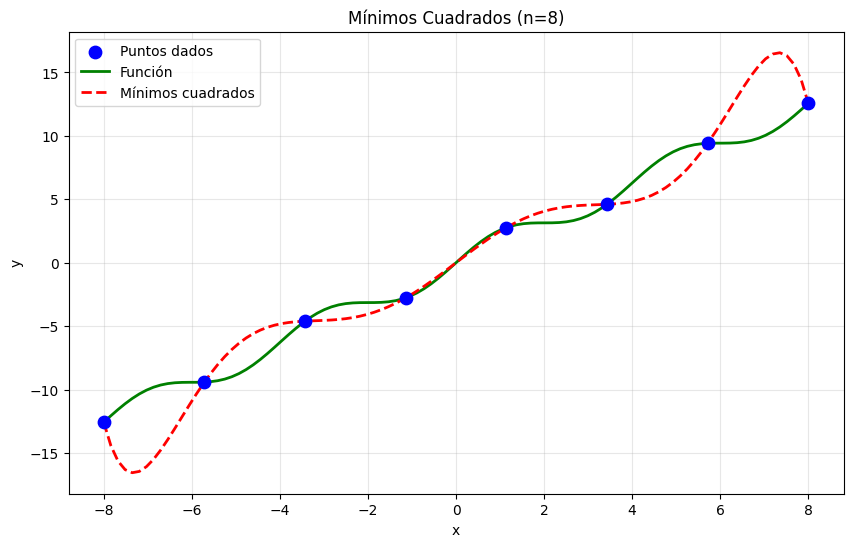

x: [-8.         -6.93333333 -5.86666667 -4.8        -3.73333333 -2.66666667
 -1.6        -0.53333333  0.53333333  1.6         2.66666667  3.73333333
  4.8         5.86666667  6.93333333  8.        ]
y: [-12.56637061  -9.89633264  -9.42325014  -8.49087888  -5.45756964
  -3.3227648   -3.10105938  -1.58090287   1.58090287   3.10105938
   3.3227648    5.45756964   8.49087888   9.42325014   9.89633264
  12.56637061]


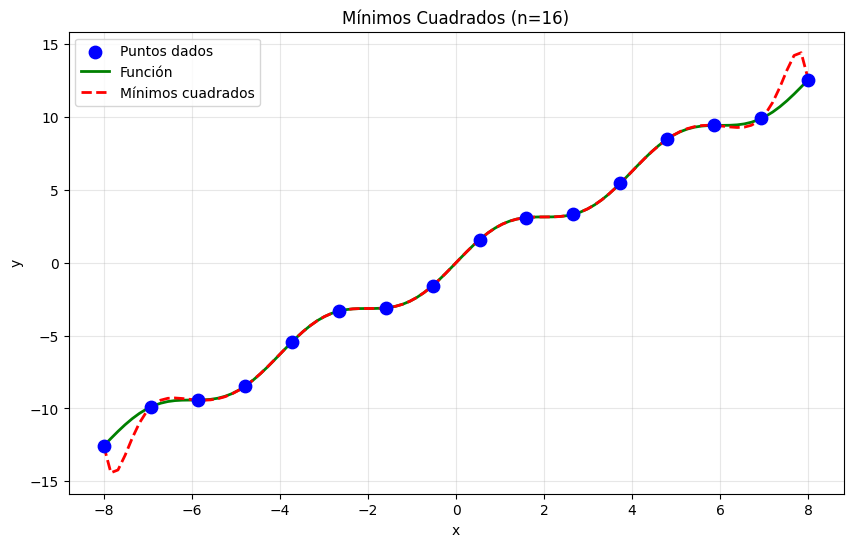

x: [-8.         -7.48387097 -6.96774194 -6.4516129  -5.93548387 -5.41935484
 -4.90322581 -4.38709677 -3.87096774 -3.35483871 -2.83870968 -2.32258065
 -1.80645161 -1.29032258 -0.77419355 -0.25806452  0.25806452  0.77419355
  1.29032258  1.80645161  2.32258065  2.83870968  3.35483871  3.87096774
  4.38709677  4.90322581  5.41935484  5.93548387  6.4516129   6.96774194
  7.48387097  8.        ]
y: [-12.56637061 -11.03084424  -9.94618693  -9.48279737  -9.42460458
  -9.30347841  -8.69043741  -7.46250371  -5.87920339  -4.42112406
  -3.49095762  -3.16299918  -3.13693068  -2.92463851  -2.15385251
  -0.79972265   0.79972265   2.15385251   2.92463851   3.13693068
   3.16299918   3.49095762   4.42112406   5.87920339   7.46250371
   8.69043741   9.30347841   9.42460458   9.48279737   9.94618693
  11.03084424  12.56637061]


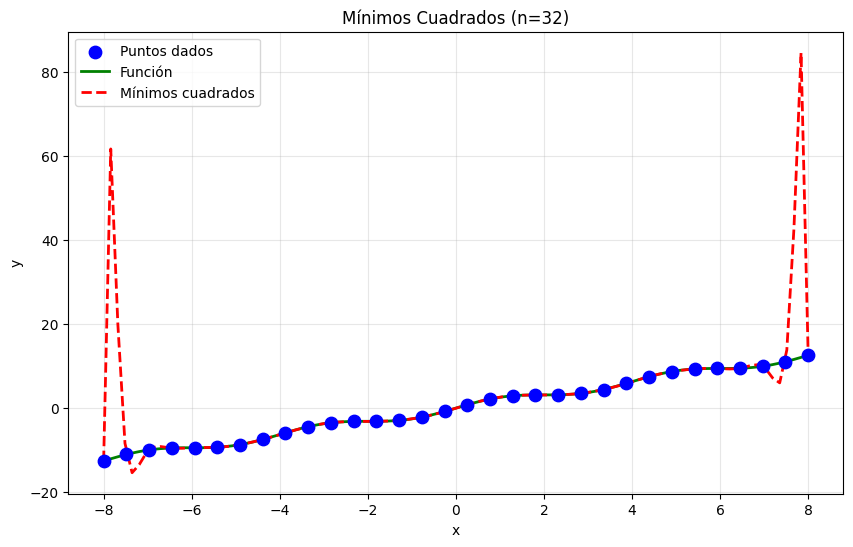

In [3]:
#  f(x) = sin(pix/2) + pix/2
from numpy import vander

enes = [2,4,8,16,32]
for n in enes:
    x = np.array(np.linspace(-8, 8, n))
    results = []
    for xd in x:
        results.append(np.sin((np.pi * xd)/2) + (np.pi * xd)/2)
    y = np.array(results)

    print(f'x: {x}\ny: {y}')

    # Vandermonde
    V = vander(x, increasing=True)

    # Minimos cuadrados
    a_mc = np.linalg.solve(V.T.dot(V),V.T.dot(y))
    p_mc = lambda t: sum(a_mc[i] * t**i for i in range(n))

    #
    xplot = np.linspace(-8, 8, 100)

    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color='blue', s=80, label='Puntos dados', zorder=5)
    plt.plot(xplot, np.sin((np.pi * xplot)/2) + (np.pi * xplot)/2, 'g-', linewidth=2, label='Función')
    plt.plot(xplot, p_mc(xplot), 'r--', linewidth=2, label='Mínimos cuadrados')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Mínimos Cuadrados (n={n})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Se puede apreciar que la aproximación por mínimos cuadrados es bastante buena en los nodos intermedios a medida que n aumenta, sin embargo no se podría decir que es una buena aproximación de la función dada. A medida que n crece, el error de aproximación para los extremos también aumenta de forma exponencial, este comportamiento es algo similar a lo que ocurría con la función de Runge si se hacía interpolación por puntos equiespaciados. 

<div class="alert alert-block alert-info"> <b> Problema 2. Curvas de Bezier </b> </div>

- Encuentre y grafique una aproximación del círculo unitario usando curvas de Bezier cuadráticas, y $n=4$ puntos. Reporte los respectivos valores de los coeficientes y puntos de control usados.
- Encuentre y grafique una aproximación del círculo unitario usando curvas de Bezier cúbicas, y n=4 puntos. Reporte los respectivos valores de los coeficientes y puntos de control usados.
- Proponga un archivo **.svg** (puede corresponder a logos o dibujos) y grafíquelo utilizando las curvas de Bezier, cúbicas o cuadráticas. Puede utilizar como ejemplo el código a continuación. 

In [4]:
def eval_cubic_bezier(P0, P1, P2, P3, t_vals): # Evalúa la curva de Bézier Cúbica
    return ((1-t_vals)**3*P0+3*(1-t_vals)**2*t_vals*P1+3*(1-t_vals)*t_vals**2*P2+t_vals**3*P3)
def eval_quadratic_bezier(P0, P1, P2, t_vals): # Evalúa la curva de Bézier Cuadrática
    return ((1-t_vals)**2*P0+2*(1-t_vals)*t_vals*P1+t_vals**2*P2)

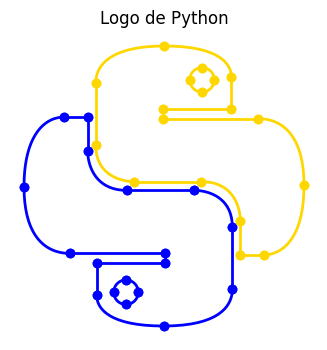

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from svgpathtools import svg2paths, CubicBezier, QuadraticBezier, Line
SVG_FILE = "Python-logo-notext.svg"
NUM_POINTS = 20  
t_vals = np.linspace(0, 1, NUM_POINTS)
try:
    paths, attributes = svg2paths(SVG_FILE)
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{SVG_FILE}'. Asegúrate de que esté en el directorio correcto.")
    exit()

plt.figure(figsize=(4, 4))
plt.title(f"Logo de Python")
plt.gca().set_aspect('equal', adjustable='box')
plt.axis('off')

for path_index, path in enumerate(paths):
    color = 'blue' if path_index == 0 else 'gold' 
    for segment in path:
        if isinstance(segment, CubicBezier):
            P0, P1, P2, P3 = segment.start, segment.control1, segment.control2, segment.end
            points = eval_cubic_bezier(P0, P1, P2, P3, t_vals)
            plt.plot(points.real, points.imag, color=color, linewidth=2)
            plt.plot([P0.real, P3.real], [P0.imag, P3.imag], 'o', color=color)
        elif isinstance(segment, QuadraticBezier):
            P0, P1, P2 = segment.start, segment.control, segment.end
            points = eval_quadratic_bezier(P0, P1, P2, t_vals)
            plt.plot(points.real, points.imag, color=color, linewidth=2)
        elif isinstance(segment, Line):
            P0, P1 = segment.start, segment.end
            plt.plot([P0.real, P1.real], [P0.imag, P1.imag], 'o', color=color)
            plt.plot([P0.real, P1.real], [P0.imag, P1.imag], color=color, linewidth=2)
plt.show()

Para el círculo unitario, recordamos que existe la siguiente relación:
$$
\sin^2(x) + \cos^2(x) = 1
$$

Para aproximar el círculo unitario se dibuja un segmento de círculo en el primer cuadrante y se replica el proceso para los cuatro cuadrantes. Se tienen como punto inicial y final: P0 = [1,0] , Pn = [0,1]. Luego, para los puntos de control se escogen por las siguientes razones:

**Tangencia:**
En nuestro punto inicial P0, la tangente debe ser vertical mientras que en Pn, debe ser horizontal, así se forma una curva suave que aproxima un semicírculo.

$$
\textbf{Cuadráticas}
$$

Se tiene un único punto de control el cual está dado por P1 =$[x,y]$. 
La tangente de la curva de Bézier cuadrática es:

$$
B'(t)= 2(1-t)(P_1 - P_0)+2t(P_2 - P_1)
$$

Con $0\leq t \leq 1$, las tangentes salen de $P_0$ en dirección a $P_1$ y se dobla hasta llegar a $P_2$ desde $P_1$.

Aplicamos la condición de tangencia:
- En $P_0 = (1,0): B'(0)= 2(P_1 - P_0) = 2(x-1 , y-0)$ 
Para tangente vertical en el punto inicial: $x-1 = 0, x=1$. 
- $P_2 = (0,1): B'(1) = 2(P_2 - P_1) = 2(0-x , 1-y)$
Para tangente horizontal en el punto final: $1-y=0, y=1$

- P1: $[1,1]$

$$
\textbf{Cúbicas}
$$

Calculamos la derivada de la curva de Bézier cúbica:

$$
B'(t) = 3(1-t)^2(P_1 - P_0)+6(1-t)t(P_2 - P_1) + 3t^2(P_3 - P_2)
$$

Aplicamos las condiciones de tangencia en los puntos inicial y final:
- En $P_0 = (1,0): B'(0)= 3(P_1 - P_0) = P_1 - P_0 = (0,p) , P_1 = (1,p)$  
- En $P_3 = (0,1): B'(1) = 3(P_3 - P_2) = P_3 - P_2 = (p,0) , P_2 = (p,1)$

Para escoger el p, tomamos el punto medio del segmento que ocurre en $\frac{\pi}{4}$, evaluendo nuestra curva en $t = 0.5$: 
$$
B(0.5) = 0.125(1,0) + 0.375(1,p) + 0.375(p,1) + 0.125(0,1) = (0.5 + 0.375p, 0.5 + 0.375p)
$$

Igualando con el punto por el que debería pasar: $\sqrt2/2$:
$$
0.5 + 0.375p = \sqrt{2}/2 \to p = (\sqrt2 / 2 - 0.5) / 0.375 =  0.5523
$$

Finalmente, los puntos de control elegidos son:

- P1: $[1.0, 0.5523]$
- P2: $[0.5523, 1.0]$

Hacemos esto para hacer un segmento de círculo y luego cambiamos los signos correspondientes para terminar el círculo:
- Cuadrante 1 (Quarter 1): [x,y]
- Cuadrante 2 (Quarter 1): [-x,y]
- Cuadrante 3 (Quarter 1): [-x,-y]
- Cuadrante 4 (Quarter 1): [x,-y]


Referencia: https://en.wikipedia.org/wiki/B%C3%A9zier_curve#Applications

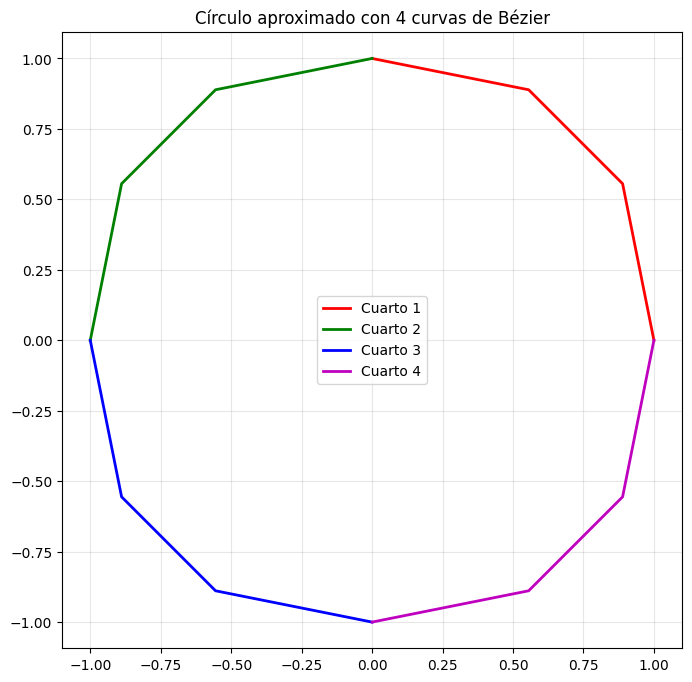

In [6]:
t_vals = np.linspace(0, 1, 4).reshape(-1, 1)

# Cuarto 1: De (1,0) a (0,1)
quarter1 = eval_quadratic_bezier(
    np.array([1.0, 0.0]),
    np.array([1.0, 1.0]),
    np.array([0.0, 1.0]),
    t_vals
)

# Cuarto 2: De (0,1) a (-1,0)  
quarter2 = eval_quadratic_bezier(
    np.array([0.0, 1.0]),
    np.array([-1, 1.0]),
    np.array([-1.0, 0.0]),
    t_vals
)

# Cuarto 3: De (-1,0) a (0,-1)
quarter3 = eval_quadratic_bezier(
    np.array([-1.0, 0.0]),
    np.array([-1.0, -1.0]),
    np.array([0.0, -1.0]),
    t_vals
)

# Cuarto 4: De (0,-1) a (1,0)
quarter4 = eval_quadratic_bezier(
    np.array([0.0, -1.0]),
    np.array([1.0, -1.0]),
    np.array([1.0, 0.0]),
    t_vals
)

# Graficar
plt.figure(figsize=(8, 8))
plt.plot(quarter1[:, 0], quarter1[:, 1], 'r-', linewidth=2, label='Cuarto 1')
plt.plot(quarter2[:, 0], quarter2[:, 1], 'g-', linewidth=2, label='Cuarto 2') 
plt.plot(quarter3[:, 0], quarter3[:, 1], 'b-', linewidth=2, label='Cuarto 3')
plt.plot(quarter4[:, 0], quarter4[:, 1], 'm-', linewidth=2, label='Cuarto 4')

plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Círculo aproximado con 4 curvas de Bézier')
plt.show()

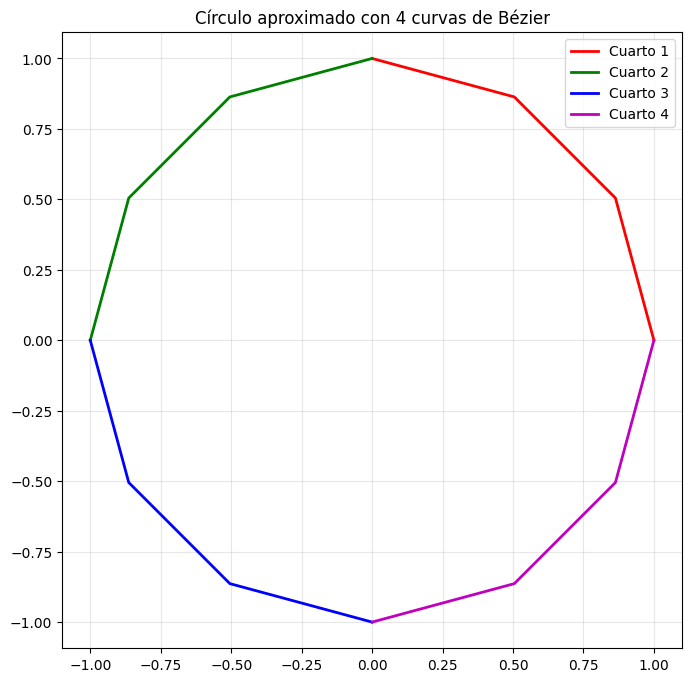

In [10]:
t_vals = np.linspace(0, 1, 4).reshape(-1, 1)

# Cuarto 1: De (1,0) a (0,1)
quarter1 = eval_cubic_bezier(
    np.array([1.0, 0.0]),
    np.array([1.0, 0.5523]),
    np.array([0.5523, 1.0]),
    np.array([0.0, 1.0]),
    t_vals
)

# Cuarto 2: De (0,1) a (-1,0)  
quarter2 = eval_cubic_bezier(
    np.array([0.0, 1.0]),
    np.array([-0.5523, 1.0]),
    np.array([-1.0, 0.5523]),
    np.array([-1.0, 0.0]),
    t_vals
)

# Cuarto 3: De (-1,0) a (0,-1)
quarter3 = eval_cubic_bezier(
    np.array([-1.0, 0.0]),
    np.array([-1.0, -0.5523]),
    np.array([-0.5523, -1.0]),
    np.array([0.0, -1.0]),
    t_vals
)

# Cuarto 4: De (0,-1) a (1,0)
quarter4 = eval_cubic_bezier(
    np.array([0.0, -1.0]),
    np.array([0.5523, -1.0]),
    np.array([1.0, -0.5523]),
    np.array([1.0, 0.0]),
    t_vals
)

# Graficar
plt.figure(figsize=(8, 8))
plt.plot(quarter1[:, 0], quarter1[:, 1], 'r-', linewidth=2, label='Cuarto 1')
plt.plot(quarter2[:, 0], quarter2[:, 1], 'g-', linewidth=2, label='Cuarto 2') 
plt.plot(quarter3[:, 0], quarter3[:, 1], 'b-', linewidth=2, label='Cuarto 3')
plt.plot(quarter4[:, 0], quarter4[:, 1], 'm-', linewidth=2, label='Cuarto 4')

plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Círculo aproximado con 4 curvas de Bézier')
plt.show()

Ahora graficamos el logo de discord del archivo svg: *discord-icon-svgrepo-com.svg*

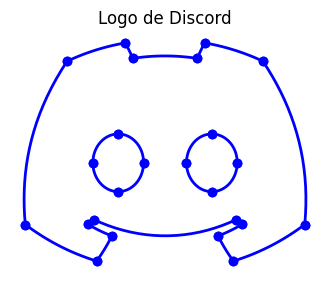

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from svgpathtools import svg2paths, CubicBezier, QuadraticBezier, Line
SVG_FILE = "discord-icon-svgrepo-com.svg"
NUM_POINTS = 20  
t_vals = np.linspace(0, 1, NUM_POINTS)
try:
    paths, attributes = svg2paths(SVG_FILE)
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{SVG_FILE}'. Asegúrate de que esté en el directorio correcto.")
    exit()

plt.figure(figsize=(4, 4))
plt.title(f"Logo de Discord")
plt.gca().set_aspect('equal', adjustable='box')
plt.axis('off')

# Esto da vuelta el sistema coordenado ya que el eje y del plot de matplotlib crece hacia arriba (plano cartesiano)
# El sistema SVG está hecho para pantallas por lo que el eje Y crece hacia abajo
# Referencia: https://www.w3.org/TR/SVG11/coords.html#InitialCoordinateSystem
plt.gca().invert_yaxis() 

for path_index, path in enumerate(paths):
    color = 'blue' if path_index == 0 else 'white' 
    for segment in path:
        if isinstance(segment, CubicBezier):
            P0, P1, P2, P3 = segment.start, segment.control1, segment.control2, segment.end
            points = eval_cubic_bezier(P0, P1, P2, P3, t_vals)
            plt.plot(points.real, points.imag, color=color, linewidth=2)
            plt.plot([P0.real, P3.real], [P0.imag, P3.imag], 'o', color=color)
        elif isinstance(segment, QuadraticBezier):
            P0, P1, P2 = segment.start, segment.control, segment.end
            points = eval_quadratic_bezier(P0, P1, P2, t_vals)
            plt.plot(points.real, points.imag, color=color, linewidth=2)
        elif isinstance(segment, Line):
            P0, P1 = segment.start, segment.end
            plt.plot([P0.real, P1.real], [P0.imag, P1.imag], 'o', color=color)
            plt.plot([P0.real, P1.real], [P0.imag, P1.imag], color=color, linewidth=2)
plt.show()

<div class="alert alert-block alert-success"> <b> Solución. </b> </div>

<div class="alert alert-block alert-info"> <b> Problema 3. Polinomio de aproximación </b> </div>

Demuestre que la aproximación por minimos cuadrados polinomial de grado menor o igual que $n$ de una función $f$ en los nodos $x_0, x_1, x_2, ..., x_n$ coincide con el polinomio interpolante de $f$ en estos mismos nodos. Además de un ejemplo numérico para $n=5$. 

<div class="alert alert-block alert-success"> <b> Solución. </b> </div>

La aproximación polinomial de una función $f$ por mínimos cuadrados es tal que:
$$
\min{\sum\limits_{i =0}^n (f(x_i) - p(x_i))^2}
$$
donde $p_{mc}(x) = a_0 + a_1 x + a_2 x^2 +\dots + a_n x^n$ minimiza lo anterior.

El problema lo podemos formular como un sistema matricial de la forma:
$$
\begin{bmatrix}
1 & x_1 & \dots & x_1^n \\
\vdots & & & \vdots \\
1 & x_n & \dots & x_n^m
\end{bmatrix}  \begin{bmatrix} a_0 \\ a_1\\ \vdots \\ a_m \end{bmatrix} = \begin{bmatrix} p(x_1) \\ p(x_2) \\ \vdots \\ p(x_n) \end{bmatrix}
$$
$$
\min\limits_{a\in\mathbb{R}^{n+1}}||Va -b||
$$

Donde $V$ es la matriz de Vandermonde, luego sabemos que en los nodos $(x_0,x_1,\dots, x_n)$: $V(x_0,x_1,\dots, x_n)a = y$ con $y = [f(x_0), f(x_1),\dots, f(x_n)]^T$. 

EL polinomio interpolante que se consigue es tal que $p_I(x_i) = f(x_i)$ para todo $i\leq n$. Luego reemplazando dicho polinomio en la ecuación de mínimos cuadrados:
$$
{\sum\limits_{i =0}^n (f(x_i) - p_I(x_i))^2} = 0
$$

Concluimos que en los nodos: $p_{mc} = p_I$.

x: [1 2 3 4 5 6]
y: [ 0  3  8 15 24 35]


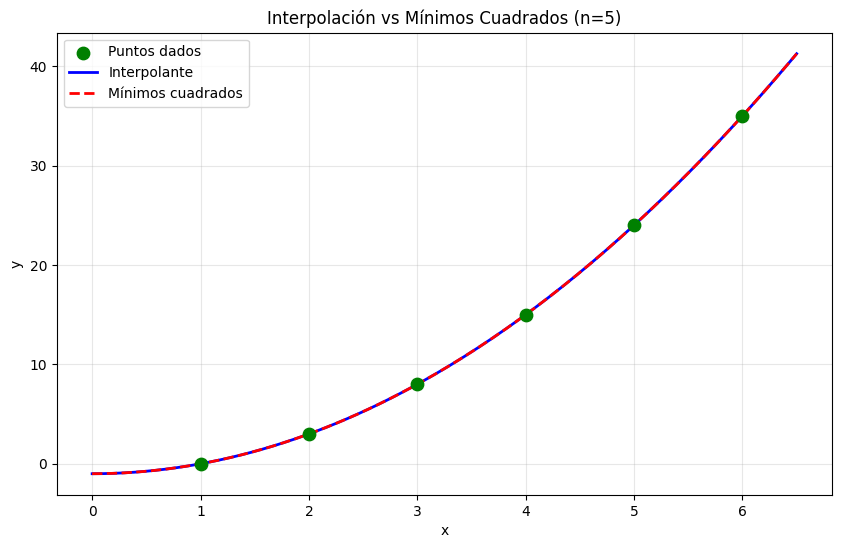

In [9]:
# Ejemplo numérico: supongamos que se quiere aproximar f(x) = x^2 - 1
from numpy import vander

x = np.array([1,2,3,4,5,6])
y = np.array([0,3,8,15,24,35])

print(f'x: {x}\ny: {y}')

# Vandermonde
V = vander(x, increasing=True)
a_interpolacion = np.linalg.solve(V, y)
p_interp = lambda t: a_interpolacion[0]+ a_interpolacion[1]*t + a_interpolacion[2]*t**2 + a_interpolacion[3]*t**3+ a_interpolacion[4]*t**4 + a_interpolacion[5]*t**5

# Minimos cuadrados
a_mc = np.linalg.solve(V.T.dot(V),V.T.dot(y))
p_mc = lambda t: a_mc[0]+ a_mc[1]*t + a_mc[2]*t**2 + a_mc[3]*t**3 + a_mc[4]*t**4 + a_mc[5]*t**5

#
xplot = np.linspace(0, 6.5, 200)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='green', s=80, label='Puntos dados', zorder=5)
plt.plot(xplot, p_interp(xplot), 'b-', linewidth=2, label='Interpolante')
plt.plot(xplot, p_mc(xplot), 'r--', linewidth=2, label='Mínimos cuadrados')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Interpolación vs Mínimos Cuadrados (n=5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div class="alert alert-block alert-info"> <b> Problema 4. Polinomios de Laguerre y Hermite </b> </div>

- Utilice el método de ortogonalizacion de Gram-Schmidt para calcular los  polinomios ortogonales de grado menor o igual que 3 con respeto al producto interior
$$<f,g> =\int_{0}^\infty e^{-x} f(x) g(x) dx$$
- Utilice el método de ortogonalizacion de Gram-Schmidt para calcular los  polinomios ortogonales de grado menor o igual que 3 con respeto al producto interior
$$<f,g> =\int_{-\infty}^\infty e^{-x^2} f(x) g(x) dx
$$

<div class="alert alert-block alert-success"> <b> Solución. </b> </div>

Para calcular los polinomios ortogonales con Gram-Schmidt, elegimos la báse canónica:
$$
\mathbb{P}^3 = \{1,x,x^2,x^3\}
$$
Calculamos los elementos $u$ de la base ortogonal a $\mathbb{P}^3$:

$$
u_1 = r_1 = 1 \ , \ v_1 = \frac{1}{||u_1||} , ||u_1|| = \sqrt{\int\limits_0^\infty e^{-x}dx} = 1
$$

Obtenemos $u_1 = 1$ y $v_1 = 1$

$$
u_2 = r_2 - <r_2, v_1> = x - <x,1> = x- \int\limits_0^\infty e^{-x}xdx
$$

Notemos algo interesante, de la forma que se nos representa el producto interno podemos relacionarla con un resultado conocido:
$$
<f,g> =\int_{0}^\infty e^{-x} f(x) g(x) dx = \int_{0}^\infty e^{-x} x^{z-1} dx = \Gamma(z)
$$
Podemos ver que la integral anterior queda:
$$
\int\limits_0^\infty e^{-x}xdx = \int\limits_0^\infty e^{-x} x^{2-1}dx = \Gamma(2) = 1
$$
Entonces:
$$
u_2 = x-1 \quad , \quad v_2 = \frac{x-1}{||x-1||} \ , \ \int\limits_0^\infty e^{-1}(x-1)^2dx = \int\limits_0^\infty e^{-x}(x^2-2x+1)dx = \int\limits_0^\infty e^{-x}x^2 dx - 2\int\limits_0^\infty e^{-x}xdx + \int\limits_0^\infty e^{-x}dx
$$

$$
= \Gamma(3) -2\Gamma(2) + 1 = 2 - 2 +1 = 1
$$
Obtenemos $u_2 = x-1$ y $v_2 = x-1$

$$
u_3 = x^2 - (<x^2,1> + <x^2,x-1>x-1) = x^2 - \int_{0}^\infty e^{-x} x^2 dx - (x-1)\int_{0}^\infty e^{-x} x^3dx - \int_{0}^\infty e^{-x} x^2 dx
$$
$$
u_3 = x^2 - 2! -4(x-1) = x^2 -2 -4x + 4 = x^2 -4x + 2
$$

$$
||u_3||^2 = \int\limits_0^\infty e^{-x}x^4 dx - 8\int\limits_0^\infty e^{-x}x^3 dx + 20 \int\limits_0^\infty e^{-x}x^2 dx -16\int\limits_0^\infty e^{-x} xdx + 4 = 24-48+40-16+4= 4
$$
$$
v_3 = \frac{x^2 -4x + 2}{2}
$$
Obtenemos $u_3 = x^2 -4x + 2$ y $v_3 =\frac{x^2 -4x + 2}{2}$

$$
u_4 = x^3 - <x^3,1>[1] - <x^3,x-1>(x-1)[2] - <x^3, \frac{x^2 -4x + 2}{2}>(\frac{x^2 -4x + 2}{2})[3]
$$
$$
[1]: \int\limits_0^\infty e^{-x} x^3 dx = 6 \ , \ [2]: \int\limits_0^\infty e^{-x}x^4dx - \int\limits_0^\infty e^{-x}x^3 dx = 24-6 = 18(x-1)
$$
$$
[3]: \frac{1}{2}(\int\limits_0^\infty e^{-x}x^5 dx - 4\int\limits_0^\infty e^{-x} x^4 dx + 2\int\limits_0^\infty e^{-x} x^3 dx) = \frac{1}{2}(5!-4\cdot4! +2\cdot 3!) = 18(\frac{x^2-4x+2}{2})
$$
$$
u_4 = x^3 -6 -18x +18 -9x^2 +36x -18 = x^3 -9x^2 +18x - 6
$$

Luego, los polinomios ortogonales a los polinomios de grado menor o igual a 3 con respecto al producto interno indicado están generados por la base:
$$
U = \{1\ ,\ x-1\ , \ x^2-4x+2\ ,\ x^3 -9x^2 +18x -6\}
$$

---

Hacemos el mismo proceso para el segundo producto interno, tomemos en cuenta el siguiente resultado:
$$
\int_{-\infty}^\infty e^{-x^2} x^{2n} dx = \Gamma(n+\frac{1}{2}) \quad , \quad \Gamma(\frac{1}{2}) = \sqrt\pi
$$

$$
u_1 = 1 \ , \ v_1 = \frac{1}{||1||} \ , \ ||1||^2= \int_{-\infty}^\infty e^{-x^2} dx = \sqrt{\pi} \ , \ v_1 = \pi^{-1/4}
$$

$$
u_2 = x - <x,\pi^{-1/4}>\pi^{-1/4} = x - \int_{-\infty}^\infty e^{-x^2} x\cdot\frac{1}{\pi^{1/4}}dx = x -0  = x
$$
$$
v_2 = \frac{x}{||x||}\ , \ ||x||^2 = \int_{-\infty}^\infty e^{-x^2} x^2dx = \frac{1}{2}\sqrt{\pi} 
$$
Obtenemos $u_2 = x$ , $v_2 = \frac{\sqrt{2}x}{\pi^{1/4}}$

$$
u_3 = x^2 - <x^2, \pi^{-1/4}>\pi^{-1/4} - <{x^2, \frac{\sqrt{2}x}{\pi^{1/4}}}>\frac{\sqrt{2}x}{\pi^{1/4}}
$$
$$
<x^2, \pi^{-1/4}> = \pi^{-1/4}\int_{-\infty}^\infty e^{-x^2}x^2 dx = \frac{1}{\pi^{-1/4}}\cdot\frac{\sqrt{\pi}}{2}=\frac{\pi^{1/4}}{2}
$$
$$
<{x^2, \frac{\sqrt{2}x}{\pi^{1/4}}}> = \frac{\sqrt{2}}{\pi^{1/4}}\int_{-\infty}^\infty e^{-x^2}x^3 dx = 0
$$
Entonces: $u_3 = x^2 - (\frac{\pi^{1/4}}{2} \cdot \frac{1}{pi^{1/4}}) = x^2 - \frac{1}{2}$


$$
||u_3||^2 = \int_{-\infty}^\infty e^{-x^2}(x^2-\frac{1}{2})^2 dx = \int_{-\infty}^\infty e^{-x^2}x^4 dx - \int_{-\infty}^\infty e^{-x^2}x^2 dx + \frac{1}{4}\int_{-\infty}^\infty e^{-x^2} dx =
$$
$$
=\frac{3}{2}\cdot\frac{1}{2}\sqrt\pi - \frac{1}{2}\sqrt\pi + \frac{\sqrt\pi}{4} = \frac{\sqrt\pi}{2}
$$
Obtenemos $u_3 = (x^2 -\frac{1}{2})$ y $v_3 = \frac{\sqrt\pi}{2}(x^2 -\frac{1}{2})$

$$
u_4 = x^3 - < x^3, \pi^{-1/4} > \pi^{-1/4} - <x^3, \frac{\sqrt{2}}{\pi^{1/4}} x> \frac{\sqrt{2}}{\pi^{1/4}} x -  <x^3, \frac{\sqrt{2}}{\pi^{1/4}} \left(x^2 - \frac12\right)> \frac{\sqrt{2}}{\pi^{1/4}} \left(x^2 - \frac12\right)
$$
$$
1. <x^3, v_1>: \int_{-\infty}^\infty e^{-x^2}x^3 \cdot \pi^{-1/4} dx = 0 \ \text{(impar)}
$$
$$
2. <x^3,v_2>: \int_{-\infty}^\infty e^{-x^2}x^3 \cdot \frac{\sqrt{2}}{\pi^{1/4}} x dx = \frac{\sqrt2}{\pi^{1/4}}\int_{-\infty}^\infty e^{-x^2}x^4 dx = \frac{3\sqrt{2}\cdot\pi^{1/4}}{4}
$$
$$
3. <x^3,v_3>: \int_{-\infty}^\infty e^{-x^2}x^3\cdot \frac{\sqrt\pi}{2}(x^2 -\frac{1}{2}) dx = \frac{\sqrt2}{\pi^{1/4}}[\int_{-\infty}^\infty e^{-x^2}x^5 dx - \frac{1}{2}\int_{-\infty}^\infty e^{-x^2}x^3 dx] = 0 \ \text{(impar)}
$$
$$
u_4 = x^3 - \frac{3\sqrt{2}\cdot\pi^{1/4}}{4} \cdot \frac{\sqrt{2}}{\pi^{1/4}}x = x^3 -\frac{3}{2}x
$$

Luego, los polinomios ortogonales a los polinomios de grado menor o igual a 3 con respecto al producto interno indicado están generados por la base:
$$
U = \{1\ ,\ x\ , \ x^2-\frac{1}{2}\ ,\ x^3 -\frac{3}{2}x \}
$$